In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
df=pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X=df.iloc[:,1:]
y=df.iloc[:,0]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
X_train.shape

(455, 30)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [7]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9912280701754386

In [9]:
result=[]
for i in range(1,16):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    result.append(accuracy_score(y_test,y_pred))

### for k value 3 it is performing best

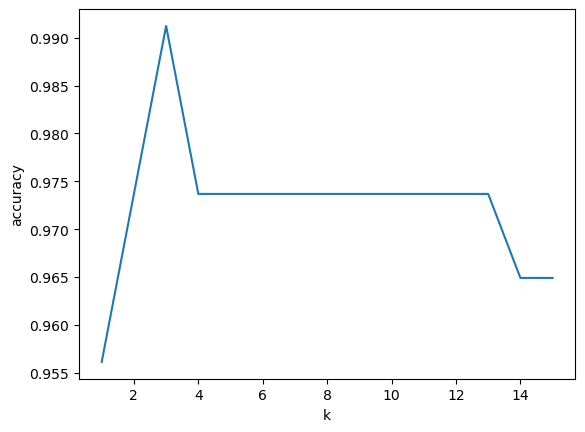

In [10]:
plt.plot(range(1,16),result)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

In [ ]:
# using manhattan distance and also weights
knn=KNeighborsClassifier(n_neighbors=3,weights='distance',metric='minkowski',p=1)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9736842105263158

### KNN from scratch

In [21]:
from collections import Counter
class KNNClassifier_Scratch():
    def __init__(self,k=3):
        self.k=k
        self.X_train=None
        self.y_train=None
    def fit(self,X_train,y_train):
        self.X_train=X_train
        self.y_train=y_train
    def predict(self,X_test):
        y_pred=[]
        # for each test point we need to calculate the distance with each X_train points
        for i in X_test:
            distance=[] # it will be X_test row no of arrays with dimention of X_train no of rows
            # for each X_train data point
            for j in self.X_train:
                distance.append(self.calculate_distance(i,j))
                # find k nearest neighbors
            n_neighbors=sorted(list(enumerate(distance)),key=lambda x:x[1])[0:self.k]# as we need index of nearest neighbors so we are doing enumerate and then sorting by distance then sorting should be based on distance(so using key) and then only we can get the index of nearest neighbor
            label=self.majority_count(n_neighbors)
            y_pred.append(label)
        return y_pred

    def calculate_distance(self,x1,x2):
        return np.linalg.norm(x1-x2)
    
    def majority_count(self,n_neighbors):
        votes=[]
        for i in n_neighbors:
            votes.append(self.y_train.iloc[i[0]])
        return Counter(votes).most_common()[0][0]
    

In [22]:
knn=KNNClassifier_Scratch(k=3)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.9912280701754386